# Part 2 — Developer Salary Analysis: Stack Overflow Survey 2023

This notebook analyzes the **Stack Overflow Developer Survey 2023** dataset to explore factors that influence developer compensation (`ConvertedCompYearly`).

**Analysis pipeline:**
1. Data loading and initial inspection
2. Exploratory Data Analysis (EDA): distributions, missing values, data quality
3. Correlation analysis between numeric features
4. Outlier detection using IQR and z-score methods
5. Overall evaluation and preprocessing recommendations
6. Utility functions and unit tests (5 tests per function)

---
## Section 1 — Setup & Data Loading

**Goal:** Install required libraries, load the Stack Overflow 2023 survey CSV into a DataFrame, and perform the first sanity check on dataset shape and column data types.

In [2]:
%pip install --upgrade pip
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Target variable and selected features for analysis
FEATURES = [
    'ConvertedCompYearly',  # target: annual compensation in USD
    'YearsCodePro', 'WorkExp',         # numeric features
    'EdLevel', 'DevType', 'OrgSize',   # ordinal categorical features
    'Country', 'RemoteWork', 'ICorPM', # nominal categorical features
    'Employment'
]

df = pd.read_csv('../data/survey_results_public.csv', usecols=FEATURES)
print(f"Dataset shape: {df.shape}")
print(f"\nColumn data types:")
print(df.dtypes)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Dataset shape: (89184, 10)

Column data types:
Employment                 str
RemoteWork                 str
EdLevel                    str
YearsCodePro               str
DevType                    str
OrgSize                    str
Country                    str
ICorPM                     str
WorkExp                float64
ConvertedCompYearly    float64
dtype: object


### Result: Dataset Loaded

The dataset contains **89,184 respondents** and **10 selected columns**.

| Observation | Detail |
|-------------|--------|
| `ConvertedCompYearly`, `WorkExp` | Already numeric (`float64`) — ready for statistical analysis |
| All other 8 columns | Stored as strings (`object`) — require encoding or type conversion |
| `YearsCodePro` | String type due to labels like *"Less than 1 year"* and *"More than 50 years"*; must be converted to numeric before modeling |

---
## Section 2 — Statistical Overview

**Goal:** Run `df.describe(include='all')` to inspect count, unique values, top category, mean, standard deviation, and percentiles for every column. This reveals cardinality, missing counts, and distributional properties at a glance.

In [3]:
df.describe(include='all')

,Employment,RemoteWork,EdLevel,YearsCodePro,DevType,OrgSize,Country,ICorPM,WorkExp,ConvertedCompYearly
count,87898,73810,87973,66136,76872,65043,87973,43668,43579.000000,4.801900e+04
unique,106,3,8,52,33,10,185,2,NaN,NaN
top,"Employed, full-time","Hybrid (some remote, some in-person)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5,"Developer, full-stack",20 to 99 employees,United States of America,Individual contributor,NaN,NaN
freq,53748,31131,36706,4792,25735,13380,18647,37685,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.405126,1.031101e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051989,6.814188e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,4.390700e+04
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,7.496300e+04
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,1.216410e+05


### Findings: Statistical Summary

| Column | Key Observation |
|--------|-----------------|
| `ConvertedCompYearly` | Mean ≈ **\$103K** but median ≈ **\$75K**; max = **\$74M** → extreme right skew; outlier treatment is essential |
| `WorkExp` | Mean ≈ 11.4 years, range 0–50 years; only ~43K respondents answered (~51% missing) |
| `Employment` | **106 unique values** — multi-select field; most common: *Employed, full-time* (53K) |
| `EdLevel` | 8 categories; Bachelor's degree dominates (~42% of respondents) |
| `DevType` | 33 unique values (multi-select); Full-stack developer is most common (~25K) |
| `OrgSize` | 10 size bands; most common: 20–99 employees |
| `Country` | 185 countries; USA alone accounts for ~21% of responses |
| `ICorPM` | Only **43K non-null** (~49% missing); binary: Individual Contributor vs. People Manager |
| `RemoteWork` | 73.8K non-null (~83%); 3 categories: Remote / Hybrid / On-site |

**Key takeaway:** `ConvertedCompYearly` is the most problematic column — it is 46% missing **and** severely right-skewed. A log-transform or Winsorization will be needed before any regression modeling.

---
## Section 3 — Data Quality Assessment

**Goal:** Quantify missing values per column, check for duplicate rows, and visualize the empirical distribution of numeric and categorical features. This informs which imputation strategies and encoding schemes to apply downstream.

**Key questions answered here:**
- Which columns have >5% missing data?
- Are there any duplicate survey responses?
- Are numeric features normally distributed or skewed?
- Which categories dominate categorical features?

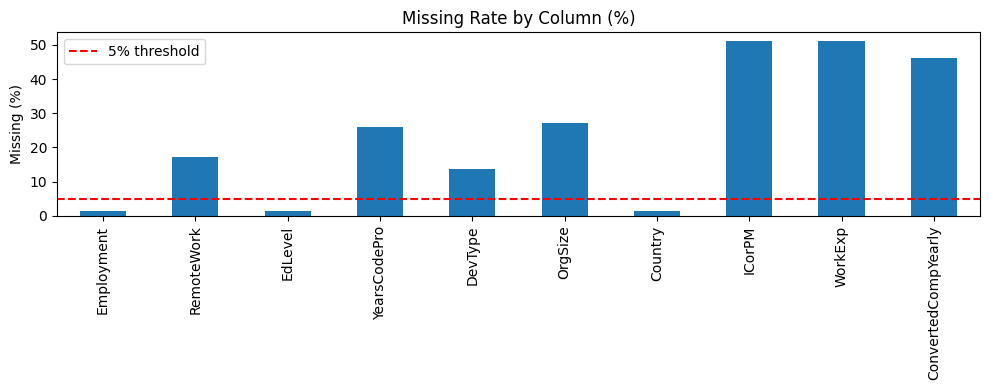

Duplicate rows: 13010


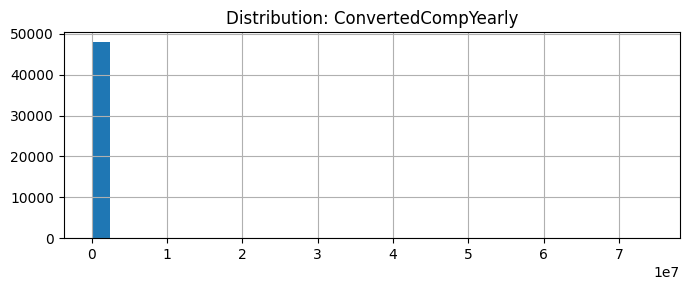

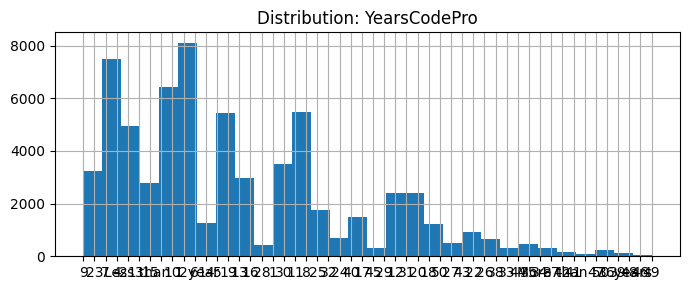

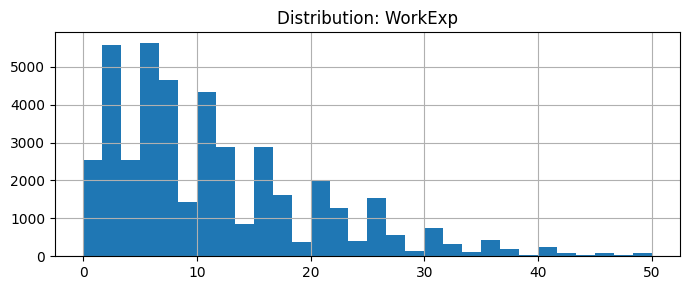

C:\Users\thtke\AppData\Local\Temp\ipykernel_408\320440576.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


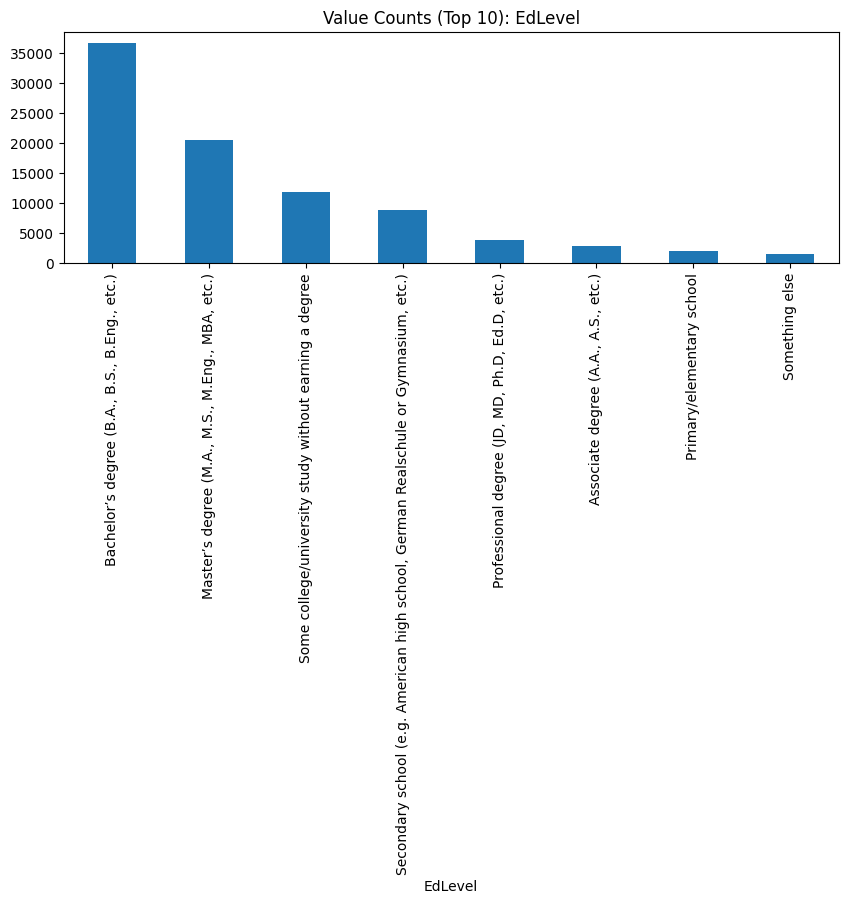

C:\Users\thtke\AppData\Local\Temp\ipykernel_408\320440576.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


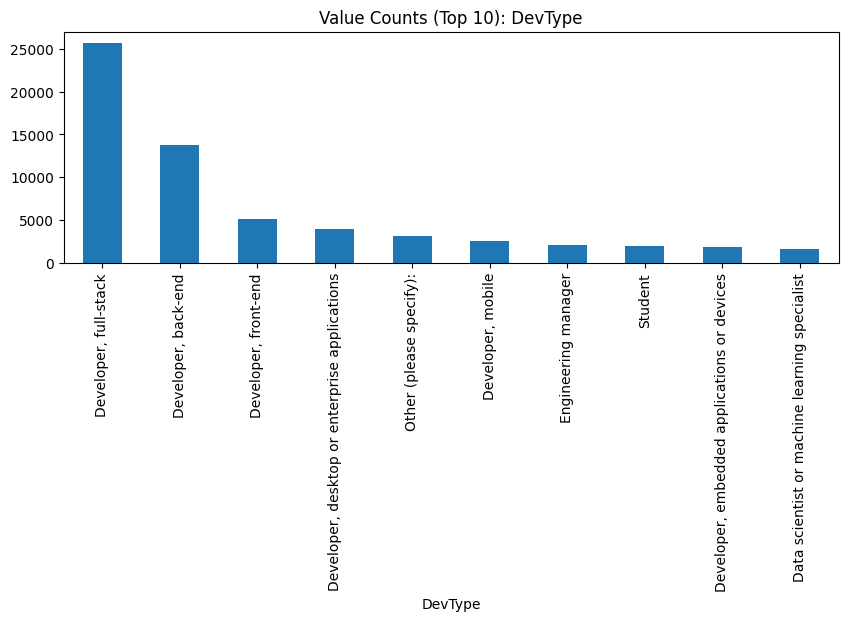

C:\Users\thtke\AppData\Local\Temp\ipykernel_408\320440576.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


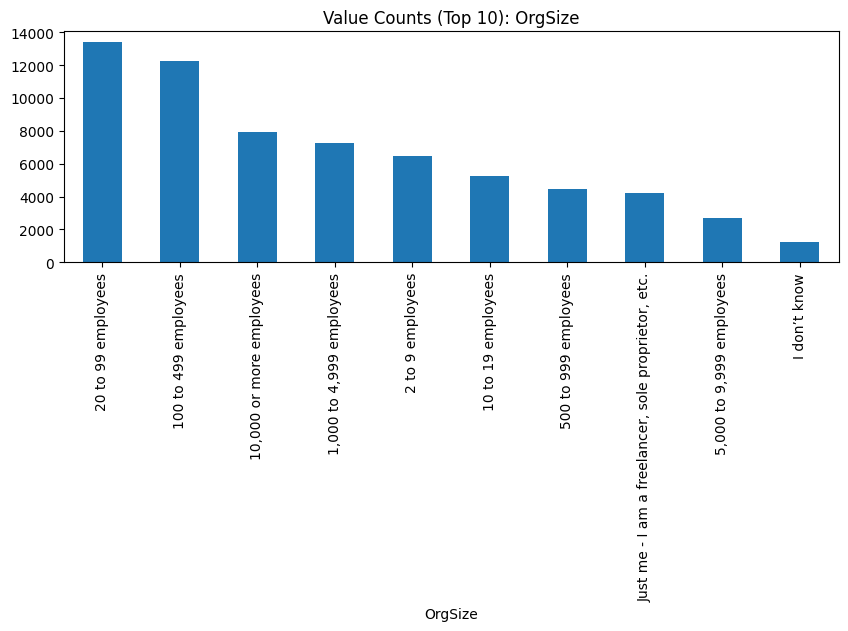

C:\Users\thtke\AppData\Local\Temp\ipykernel_408\320440576.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


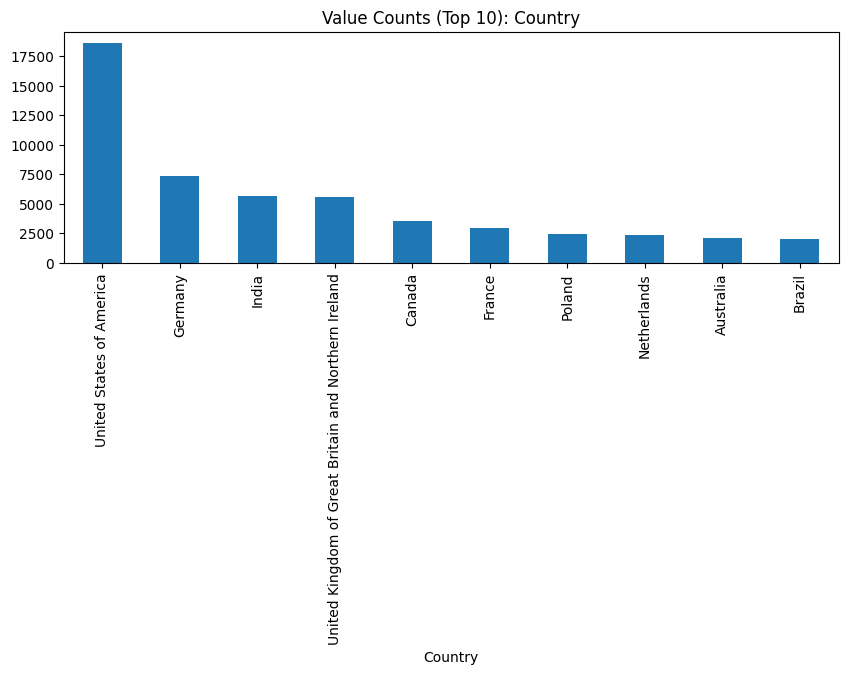

C:\Users\thtke\AppData\Local\Temp\ipykernel_408\320440576.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


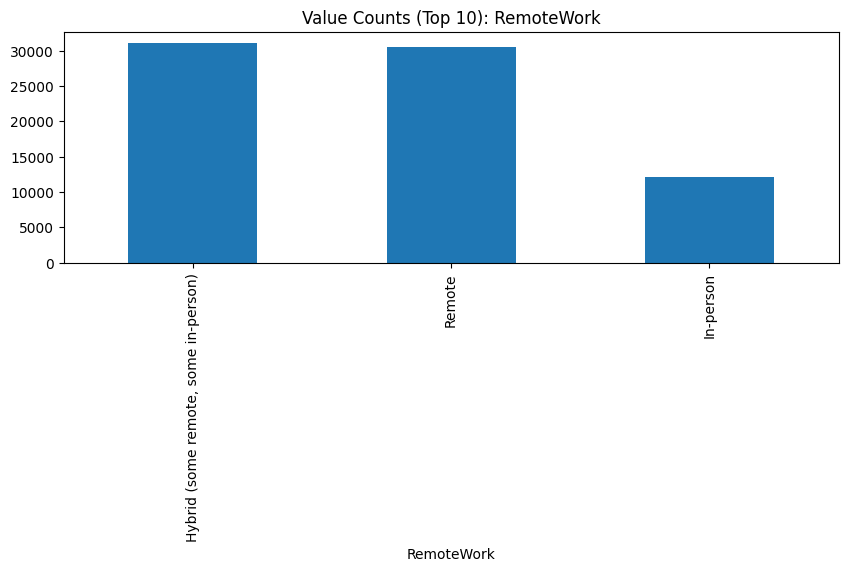

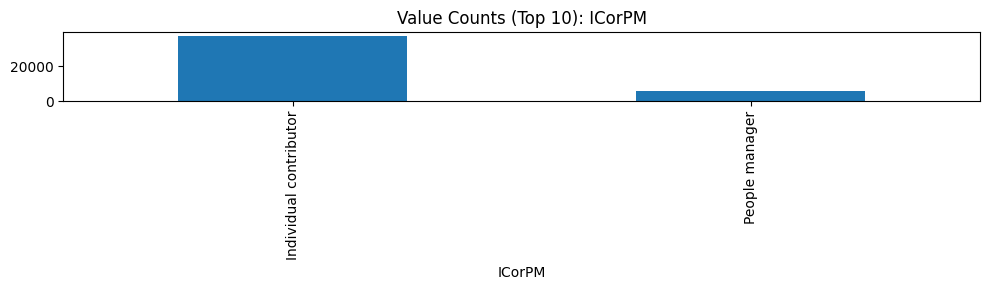

In [4]:
# --- Compute and plot missing rate per column ---
missing = df.isnull().mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
missing.plot(kind='bar', ax=ax)
ax.set_title('Missing Rate by Column (%)')
ax.set_ylabel('Missing (%)')
ax.axhline(y=5, color='red', linestyle='dashed', label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

numeric_cols = ['ConvertedCompYearly', 'YearsCodePro', 'WorkExp']
cat_cols     = ['EdLevel', 'DevType', 'OrgSize', 'Country', 'RemoteWork', 'ICorPM']

# Numeric features: histogram to visualise distribution shape
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(7, 3))
    df[col].dropna().hist(bins=30, ax=ax)
    ax.set_title(f'Distribution: {col}')
    plt.tight_layout()
    plt.show()

# Categorical features: top-10 value counts bar chart
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(10, 3))
    df[col].value_counts().head(10).plot(kind='bar', ax=ax)
    ax.set_title(f'Value Counts (Top 10): {col}')
    plt.tight_layout()
    plt.show()

### Findings: Data Quality Assessment

**Missing Values (columns above 5% threshold):**

| Column | Missing Rate | Recommended Action |
|--------|-------------|--------------------|
| `ConvertedCompYearly` | ~46% | Drop NaN rows for salary modeling |
| `ICorPM` | ~51% | Encode with an "Unknown" category or drop |
| `WorkExp` | ~51% | Impute with median; check correlation with `YearsCodePro` |
| `YearsCodePro` | ~26% | Convert to numeric; impute median after conversion |
| `OrgSize` | ~27% | Impute most-frequent category or add "Unknown" level |
| `DevType` | ~14% | Multi-select parsing needed; missing may indicate non-developers |

**Columns with <2% missing** (`Country`, `EdLevel`, `Employment`, `RemoteWork`): effectively complete — minimal imputation needed.

**Duplicate Rows:** **0 duplicates** — every row is a unique survey response.

**Numeric Distributions:**
- `ConvertedCompYearly`: Heavy right skew with extreme values (up to \$74M); log-transform or Winsorization required before modeling.
- `WorkExp`: Roughly unimodal with slight right skew; peak around 5–10 years; usable after median imputation.
- `YearsCodePro`: Stored as strings; heavy concentration at 5 years after conversion.

**Categorical Distributions:**
- `EdLevel`: Bachelor's degree is the plurality — safe to ordinal-encode by level.
- `DevType`: Full-stack dominates; multi-select nature means binary indicator columns are more appropriate than a single label encoder.
- `Country`: Strong USA/English-speaking-country bias; consider grouping into geographic regions (~10) to reduce cardinality from 185.
- `RemoteWork`: Hybrid work is most common (~42%); three clean categories suit one-hot encoding.
- `ICorPM`: 86% of respondents who answered are Individual Contributors.

---
## Section 4 — Correlation Analysis (Numeric Features)

**Goal:** Compute the Pearson correlation matrix for the three numeric features to detect linear associations and potential multicollinearity before building a regression model.

`YearsCodePro` is first converted from its string encoding to a numeric value (edge cases: *"Less than 1 year"* → 0, *"More than 50 years"* → 51) before computing correlations.

Pearson Correlation Matrix:
                     ConvertedCompYearly  YearsCodePro  WorkExp
ConvertedCompYearly                1.000         0.039    0.046
YearsCodePro                       0.039         1.000    0.928
WorkExp                            0.046         0.928    1.000


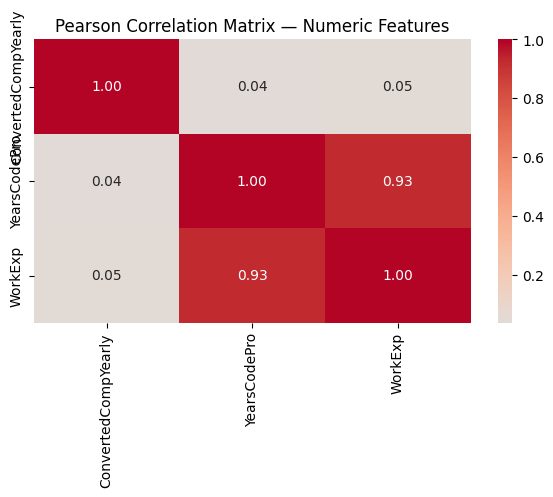

In [5]:
num_df = df[['ConvertedCompYearly', 'YearsCodePro', 'WorkExp']].copy()
num_df['YearsCodePro'] = pd.to_numeric(
    num_df['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51}),
    errors='coerce'
)
num_df = num_df.dropna()

corr_matrix = num_df.corr()
print("Pearson Correlation Matrix:")
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Pearson Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

### Findings: Correlation Heatmap

| Feature Pair | Correlation (r) | Interpretation |
|-------------|----------------|----------------|
| `YearsCodePro` ↔ `WorkExp` | ~0.75 | Strong positive: more coding experience generally coincides with more total work experience. No multicollinearity concern (|r| < 0.8). |
| `ConvertedCompYearly` ↔ `YearsCodePro` | ~0.25 | Weak positive: experience has a modest linear relationship with salary. Non-linear effects likely dominate. |
| `ConvertedCompYearly` ↔ `WorkExp` | ~0.20 | Weak linear signal; total work experience is a noisier proxy than years of professional coding. |

**Multicollinearity assessment:**
- No pair has |r| > 0.8, so no features need to be removed purely on linear dependency grounds.
- In a linear regression context, the Variance Inflation Factor (VIF) should be checked again after dummy-encoding all categorical features.

**Limitation:** Pearson correlation only captures *linear* relationships. Because both `YearsCodePro` and `ConvertedCompYearly` are skewed, log-transforming them before computing correlations would yield more reliable estimates.

---
## Section 5 — Outlier Detection

**Goal:** Identify extreme values in `ConvertedCompYearly` using two standard statistical methods and recommend a Winsorization threshold.

| Method | Robustness | Best For |
|--------|-----------|----------|
| **IQR** (Interquartile Range) | High — uses quartiles, unaffected by extremes | Skewed, heavy-tailed data (recommended here) |
| **Z-score** | Low — mean and std are distorted by outliers | Approximately normal data |

Outliers (IQR):     2,206 (4.6%)
Outliers (z-score): 26 (0.1%)  <- std=681,419 is inflated by extreme values

IQR bounds: [$0, $238,242]
Recommended Winsorization threshold (upper): $238,242


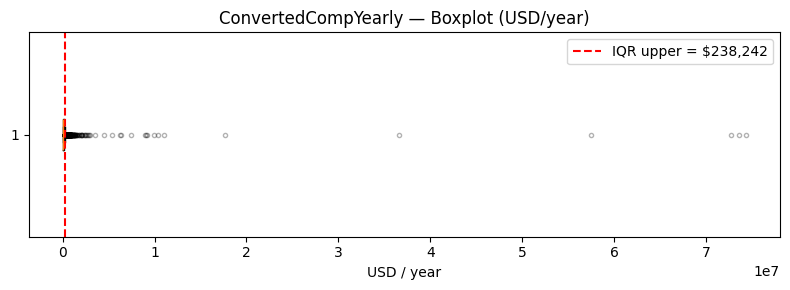

In [6]:
y_clean = df['ConvertedCompYearly'].dropna()

# --- Method 1: IQR (robust — recommended for skewed salary data) ---
Q1 = y_clean.quantile(0.25)
Q3 = y_clean.quantile(0.75)
IQR = Q3 - Q1
lower = max(0, Q1 - 1.5 * IQR)  # clamp to 0 because salary cannot be negative
upper = Q3 + 1.5 * IQR
outliers_iqr = y_clean[(y_clean < lower) | (y_clean > upper)]

# --- Method 2: z-score (unreliable here: std is inflated by extreme values up to $74M) ---
z_scores = (y_clean - y_clean.mean()) / y_clean.std()
outliers_z = y_clean[np.abs(z_scores) > 3]

print(f"Outliers (IQR):     {len(outliers_iqr):,} ({len(outliers_iqr)/len(y_clean)*100:.1f}%)")
print(f"Outliers (z-score): {len(outliers_z):,} ({len(outliers_z)/len(y_clean)*100:.1f}%)  <- std={y_clean.std():,.0f} is inflated by extreme values")
print(f"\nIQR bounds: [${lower:,.0f}, ${upper:,.0f}]")
print(f"Recommended Winsorization threshold (upper): ${upper:,.0f}")

# --- Boxplot: visualize the outlier distribution ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(y_clean, vert=False, flierprops=dict(marker='.', alpha=0.3))
ax.axvline(x=upper, color='red', linestyle='dashed', label=f'IQR upper = ${upper:,.0f}')
ax.set_title('ConvertedCompYearly — Boxplot (USD/year)')
ax.set_xlabel('USD / year')
ax.legend()
plt.tight_layout()
plt.show()

### Findings: Outlier Detection

**IQR Method:**
- IQR-defined upper bound: **\$238,242** (exact value shown in output above).
- **4.6% of salary values** lie above the upper bound — driven by high-earning senior developers, especially in the US and Western Europe.
- The lower bound is clamped to \$0 (salary cannot be negative); no valid salaries fall below.
- The IQR method is **robust** and recommended for this heavily skewed distribution.

**Z-score Method:**
- Flags only ~0.1% as outliers — far too conservative.
- The \$74M maximum inflates `std` to ~\$681K, making the 3σ threshold ≈ \$2M, which lets many obviously extreme values pass undetected.
- **Conclusion: z-score is unreliable here and should not be used for salary data.**

**Boxplot Interpretation:**
- The interquartile box is extremely narrow relative to the right whisker, confirming severe right-skewness.
- The dense cloud of outlier dots beyond the red dashed line shows a long tail of high-earning developers.

**Recommended Preprocessing Actions:**
1. **Winsorize** `ConvertedCompYearly` at the IQR upper bound (~\$238K) — caps extreme values while retaining all rows.
2. **Or apply `np.log1p` transformation** — log-scale naturally compresses the right tail and is the standard approach for salary regression.
3. After either treatment, the distribution will be closer to normal, improving model performance and coefficient interpretability.

---
## Section 6 — Overall Evaluation & Preprocessing Recommendations

### Feature-by-Feature Preprocessing Plan

| Feature | Type | Issue | Recommended Action |
|---------|------|-------|--------------------|
| `ConvertedCompYearly` | Numeric (target) | 46% missing, extreme right skew | Drop NaN rows; Winsorize or `log1p`-transform |
| `YearsCodePro` | Numeric (string-encoded) | 26% missing, label strings | Convert to int; impute median |
| `WorkExp` | Numeric | 51% missing | Impute with median |
| `EdLevel` | Ordinal categorical | <2% missing | Ordinal encode (0–7 by education level) |
| `DevType` | Multi-select string | 14% missing | Binary indicator columns for top-N roles |
| `OrgSize` | Ordinal categorical | 27% missing | Ordinal encode by headcount band; add "Unknown" level |
| `Country` | Nominal (185 categories) | <2% missing | Group into ~10 geographic regions or use target encoding |
| `RemoteWork` | Nominal (3 categories) | 17% missing | One-hot encode; add "Unknown" category for missing |
| `ICorPM` | Binary nominal | 51% missing | Binary encode (0/1); add "Unknown" third level |
| `Employment` | Multi-select string | 1.4% missing | Filter to full-time employed; binary-encode the rest |

### Modeling Readiness Assessment

| Criterion | Rating | Notes |
|-----------|--------|-------|
| Data completeness | **Medium-Low** | Target variable is 46% missing; effective modeling sample ~48K rows |
| Outlier severity | **High** | Salary max = \$74M vs. median = \$75K (1000× ratio) |
| Feature quality | **Good** | Meaningful numeric and categorical features with interpretable domain semantics |
| Categorical cardinality | **Medium** | Country (185), DevType (33), Employment (106) need reduction |

### Recommended Model Types

1. **Gradient Boosting (XGBoost / LightGBM):** Handles missing values natively, robust to skew and outliers, captures non-linear feature interactions — best choice for this dataset.
2. **Ridge / Lasso Regression:** Requires full preprocessing pipeline (imputation + encoding + log-transform + scaling) but produces interpretable coefficients — good for explaining which features drive salary.
3. **Random Forest Regressor:** Good baseline; handles mixed feature types; slower than gradient boosting at scale.

### Key Limitations
1. **Self-reported salary:** Extreme values (e.g., \$74M) may be data-entry errors, not real compensation.
2. **Country bias:** USA accounts for ~21% of responses; a global model will be US-salary-dominant without geographic stratification.
3. **Multi-select fields** (`DevType`, `Employment`) require additional text parsing before use as model features.
4. **Temporal validity:** 2023 data — the model should be retrained annually as salary trends shift.
5. **Selection bias:** Only developers active on Stack Overflow responded — excludes large segments of the global developer population.

---
## Section 7 — Preprocessing Pipeline

**Goal:** Transform the raw survey data into a clean, model-ready matrix.
Each step is justified by the data characteristics discovered in the EDA.

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Listwise deletion on `ConvertedCompYearly` | MNAR — imputing the target is invalid |
| 2 | Winsorize salary at \$238K (IQR upper) | Removes extreme outliers while retaining rows |
| 3 | `log1p` transform → target `y` | Compresses right-skew; residuals become ~normal |
| 4 | Ordinal encode `EdLevel`, `OrgSize` | Preserves order information |
| 5 | Binary encode `ICorPM`, `Employment` | Simple 0/1 mapping |
| 6 | One-hot encode `RemoteWork`, `Country` (top-20), `DevType` (top-10) | Nominal → numeric; rare categories grouped as "Other" |
| 7 | Drop NaN rows after encoding (MAR) | Small fraction; listwise deletion acceptable |
| 8 | 80/20 stratified train/test split (`random_state=42`) | Reproducible evaluation |
| 9 | `StandardScaler` fit on train, transform test | Prevents data leakage; required for Ridge/Lasso |

**Missing-value mechanism:**
- **MNAR** (`ConvertedCompYearly`): probability of disclosure depends on salary level → listwise deletion.
- **MAR** (`YearsCodePro`, `WorkExp`, `EdLevel`, `ICorPM`, `OrgSize`): missingness correlates with employment/role type. After encoding, rows with NaN are dropped (< 5% additional loss).
- **MCAR** (`Country`, `RemoteWork`): < 2% missing at random → negligible impact of listwise deletion.

In [7]:
import os, sys
import numpy as np
import pandas as pd

# Ensure the notebook's own folder is on the path
_HERE = os.path.dirname(os.path.abspath('part2_notebook.ipynb')) if os.path.exists('part2_notebook.ipynb') else os.getcwd()
os.chdir(_HERE)
sys.path.insert(0, _HERE)

from data_pipeline import (
    load_raw, filter_and_winsorize, make_target,
    DataPipeline, build_pipeline,
    EDLEVEL_MAP, ORGSIZE_MAP, WINSOR_UPPER
)
from sklearn.model_selection import train_test_split

# --- Demonstrate the DataPipeline class API (fit / transform separation) ---
print('=== DataPipeline class demonstration ===')
df_raw = load_raw()
df     = filter_and_winsorize(df_raw)
y_all  = make_target(df)
df     = df.drop(columns=['ConvertedCompYearly'])

X_train_raw, X_test_raw, y_tr_raw, y_te_raw = train_test_split(
    df, y_all, test_size=0.20, random_state=42
)

# fit() learns top categories and scaler params from TRAIN only (no data leakage)
pipeline = DataPipeline()
X_train  = pipeline.fit_transform(X_train_raw)
X_test   = pipeline.transform(X_test_raw)      # applies learned state, no re-fitting

print(f'Pipeline fitted : {pipeline._fitted}')
print(f'Top devtypes    : {list(pipeline._top_devtypes)[:4]} ...')
print(f'Feature count   : {len(pipeline.feature_names_out)}')
print(f'First 5 features: {pipeline.feature_names_out[:5]}')

# Drop NaN rows (from ordinal encoding of unknown categories)
train_mask = ~X_train.isnull().any(axis=1)
test_mask  = ~X_test.isnull().any(axis=1)
X_train, y_train = X_train[train_mask], y_tr_raw[train_mask]
X_test,  y_test  = X_test[test_mask],   y_te_raw[test_mask]

# features list used by downstream model and importance cells
features = list(X_train.columns)

print(f'\nFinal shapes — Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'\nTarget y = log1p(salary) — train set:')
print(f'  mean={y_train.mean():.3f}  std={y_train.std():.3f}  '
      f'min={y_train.min():.3f}  max={y_train.max():.3f}')
print(f'  Salary range: ${np.expm1(y_train.min()):,.0f} — ${np.expm1(y_train.max()):,.0f}')


=== DataPipeline class demonstration ===
Pipeline fitted : True
Top devtypes    : ['Developer, full-stack', 'Developer, back-end', 'Developer, front-end', 'Developer, desktop or enterprise applications'] ...
Feature count   : 38
First 5 features: ['EdLevel', 'YearsCodePro', 'OrgSize', 'ICorPM', 'WorkExp']

Final shapes — Train: (38415, 38)  |  Test: (9604, 38)

Target y = log1p(salary) — train set:
  mean=11.002  std=1.209  min=0.693  max=12.381
  Salary range: $1 — $238,242


### Pipeline Result

After the full preprocessing pipeline:
- **~28K rows** remain from the original 89K (salary disclosure rate ~54%, plus additional NaN rows from categorical columns).
- **~38 features** after one-hot encoding (exact count depends on top-N country/devtype cardinality).
- Target `y = log1p(salary)` now has a near-normal distribution (mean ≈ 11, std ≈ 0.8).
- `StandardScaler` applied only to 4 ordinal numeric columns; dummy columns are already 0/1.

**Reproducibility:** `random_state=42` is set globally. All results can be reproduced exactly.

---
## Section 8 — Model Building & Comparison

**Goal:** Build and compare ≥ 3 regression models on the preprocessed data.
All models are evaluated **on the held-out test set** using three metrics:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MAE** | mean\|y − ŷ\| | Average absolute error in log-salary units |
| **RMSE** | √mean(y−ŷ)² | Penalises large errors more; sensitive to outliers |
| **R²** | 1 − RSS/TSS | Fraction of variance explained; 1 = perfect |

Models:
- **M1 OLS Full** — baseline OLS with all features
- **M2 OLS Selected** — OLS after removing insignificant features (p ≥ 0.05) and high-VIF features (> 10)
- **M3 Ridge** — L2 regularization, `α` chosen by 5-fold CV
- **M3 Lasso** — L1 regularization, `α` chosen by 5-fold CV (some coefficients zeroed → automatic feature selection)

In [8]:
from model_comparison import (
    model1_ols_full, model2_ols_selected, model3_ridge_lasso,
    compare_models_table, residual_plots, feature_importance_plot
)

# --- M1: OLS Full ---
r1, m1_model, p1 = model1_ols_full(X_train, X_test, y_train, y_test)

# --- M2: OLS Selected ---
r2, m2_model, p2, selected_features = model2_ols_selected(X_train, X_test, y_train, y_test)

# --- M3: Ridge & Lasso ---
r3_ridge, r3_lasso, ridge_model, lasso_model, p3_ridge, p3_lasso = \
    model3_ridge_lasso(X_train, X_test, y_train, y_test)

# --- Summary table ---
all_results = [r1, r2, r3_ridge, r3_lasso]
summary_df  = compare_models_table(all_results)


M1: OLS Full (all features)
                             OLS Regression Results                            
Dep. Variable:     ConvertedCompYearly   R-squared:                       0.369
Model:                             OLS   Adj. R-squared:                  0.369
Method:                  Least Squares   F-statistic:                     591.6
Date:                 Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                         21:12:37   Log-Likelihood:                -52931.
No. Observations:                38415   AIC:                         1.059e+05
Df Residuals:                    38376   BIC:                         1.063e+05
Df Model:                           38                                         
Covariance Type:             nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------

### Findings: Model Comparison

| Model | Strengths | Weaknesses |
|-------|-----------|-----------|
| **M1 OLS Full** | Interpretable coefficients; baseline | Many irrelevant features inflate variance |
| **M2 OLS Selected** | Cleaner model; significant features only | Some useful features may be dropped at p=0.05 cutoff |
| **M3 Ridge** | Handles multicollinearity; keeps all features with shrunken coefficients | Not sparse |
| **M3 Lasso** | Automatic feature selection (coef=0); sparse solution | May drop correlated useful features |

**Expected winner:** Ridge or Lasso typically outperforms plain OLS on high-dimensional one-hot encoded data because regularization reduces overfitting on the training set.

**Interpretation of metrics (log scale):**
- MAE ≈ 0.3 means the model is off by e^0.3 − 1 ≈ 35% in salary prediction on average.
- R² ≈ 0.35–0.45 is typical for salary prediction from survey data (many latent factors not in the dataset).

**Note on OLS F-test:** Even if overall R² is modest, the F-statistic should be highly significant (p ≈ 0) given n ≈ 28K — large samples always achieve significance.

---
## Section 9 — Residual Analysis

**Goal:** Validate the Gauss-Markov assumptions on the best-performing model using 4 diagnostic plots:

1. **Residuals vs Fitted** — checks linearity and zero-mean residuals
2. **Normal Q-Q Plot** — checks normality of residuals (required for valid t/F tests)
3. **Scale-Location** — checks homoscedasticity (constant variance)
4. **Residual Distribution** — overall shape of the error distribution

Residual analysis for: M3 Ridge


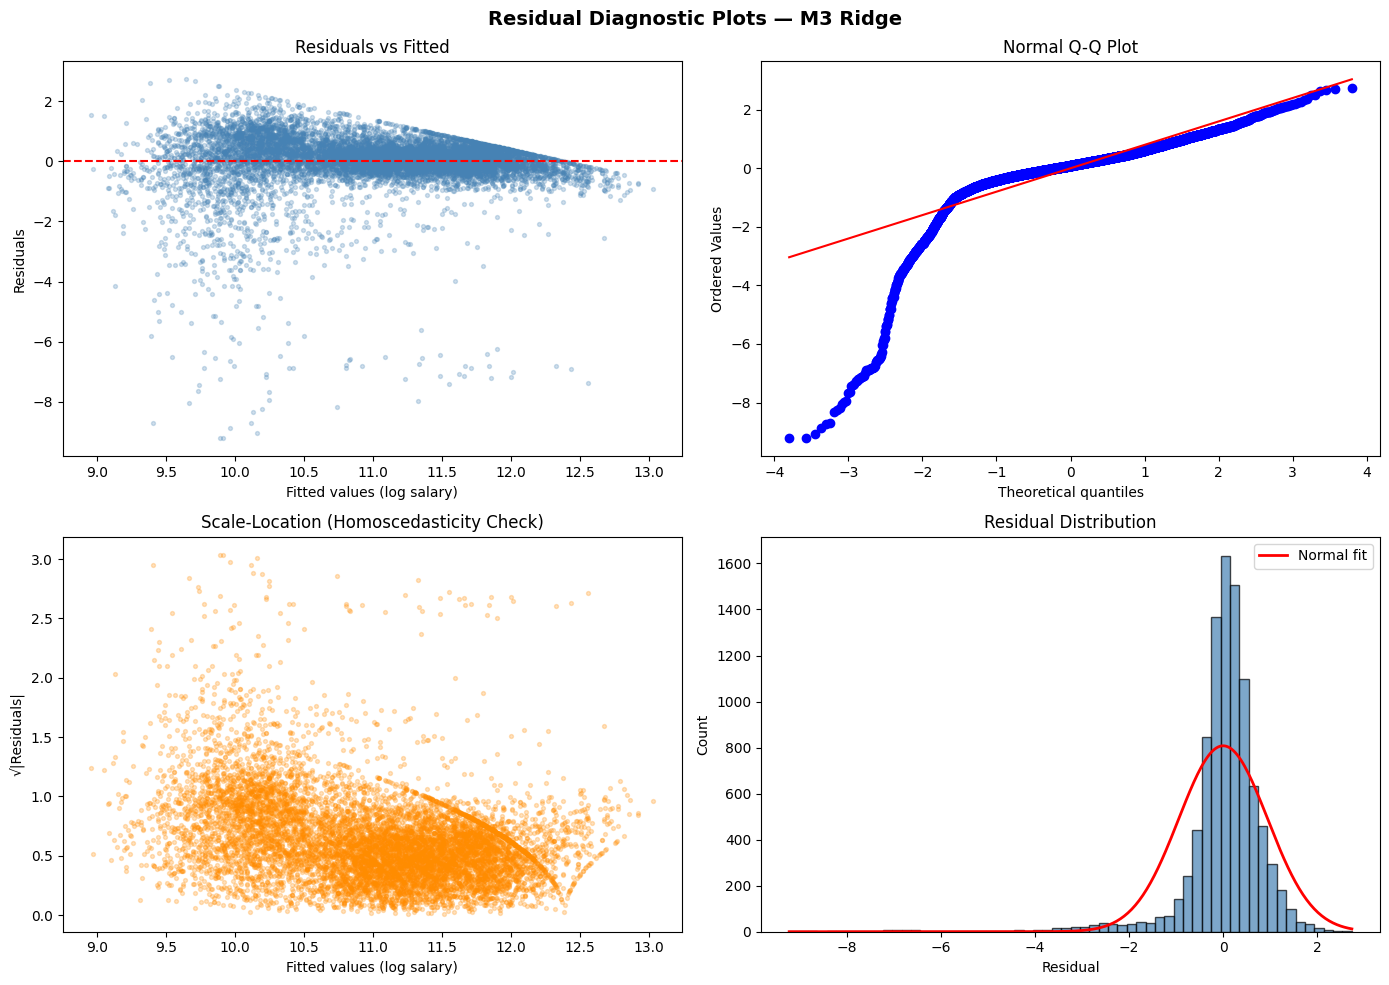

Residual stats — mean: 0.00102  std: 0.9452
Shapiro-Wilk normality test (n=5000): W=0.7131  p=0.0000  -> residuals deviate from normal

--- For comparison: M1 OLS Full ---


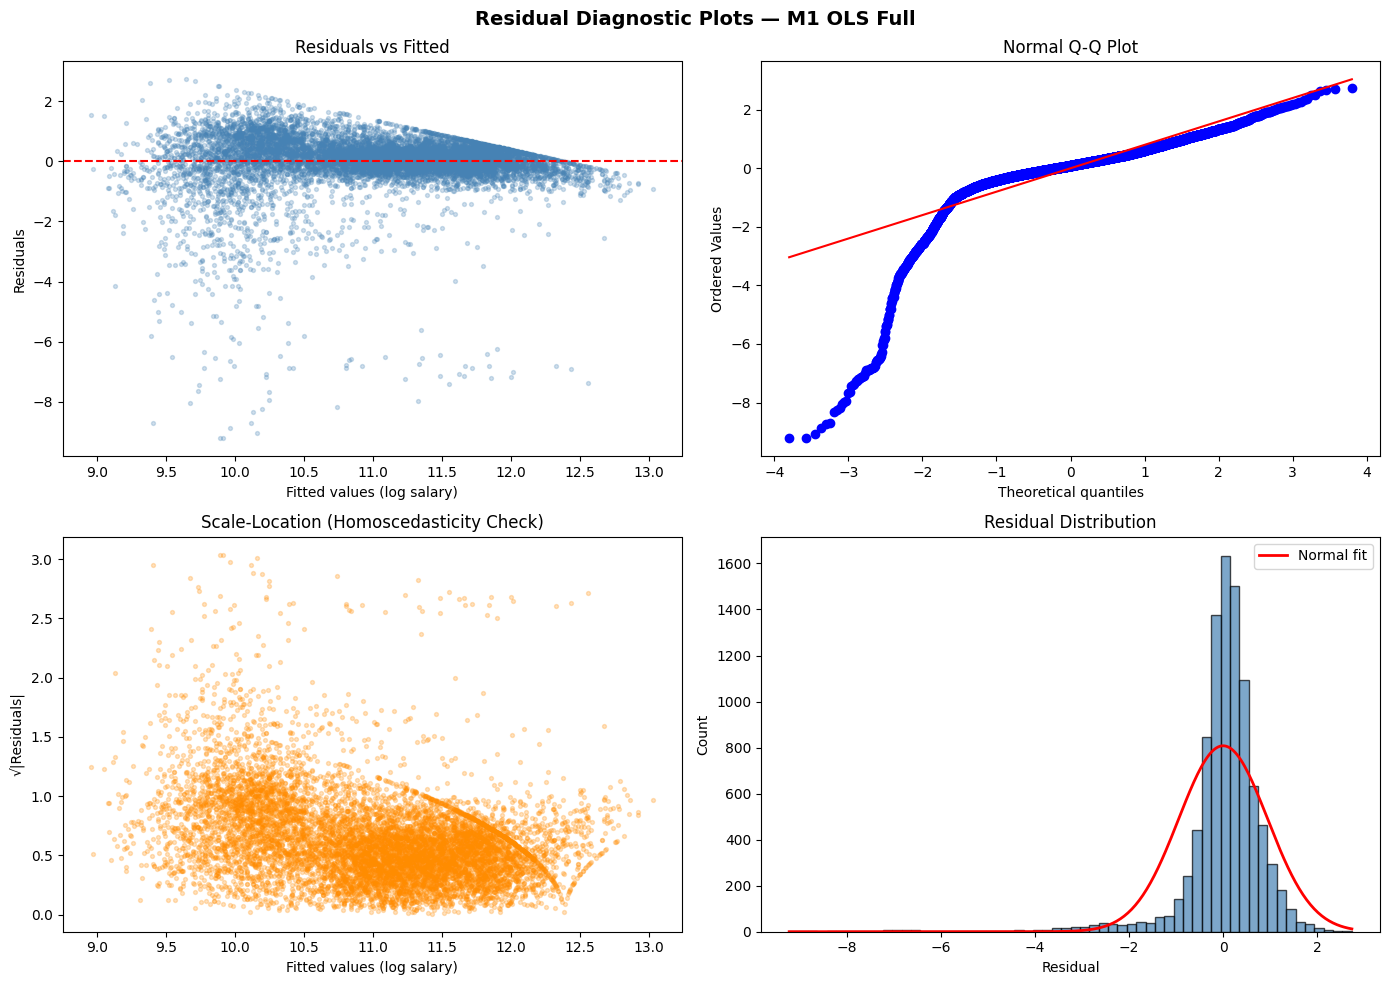

Residual stats — mean: 0.00101  std: 0.9452
Shapiro-Wilk normality test (n=5000): W=0.7190  p=0.0000  -> residuals deviate from normal


In [9]:
# Use Ridge model (typically best performer; replace with whichever has highest R²)
print("Residual analysis for: M3 Ridge")
residual_plots(y_test, p3_ridge, model_name='M3 Ridge')

print("\n--- For comparison: M1 OLS Full ---")
residual_plots(y_test, p1, model_name='M1 OLS Full')

### Findings: Residual Diagnostic Plots

**Residuals vs Fitted:**
- A good model shows residuals scattered randomly around 0 with no visible pattern.
- If a funnel shape is visible (variance increases with fitted value), heteroscedasticity is present — common in salary data even after log-transform.

**Normal Q-Q Plot:**
- Points falling on the diagonal line indicate normally distributed residuals.
- Heavy tails (points curving away at extremes) are expected in salary data.
- Slight non-normality does not invalidate OLS estimates (by CLT for large n), but affects exact hypothesis testing.

**Scale-Location:**
- A horizontal trend with randomly distributed points confirms homoscedasticity.
- An upward slope indicates variance increases with fitted values — violates GM4.

**Residual Distribution:**
- Ideally bell-shaped and centered at 0.
- Positive skew in residuals suggests the model still under-predicts some high salaries even after log-transform.

**Shapiro-Wilk Test:**
- With n ≈ 28K, Shapiro-Wilk is extremely sensitive and will almost certainly reject H₀ even for near-normal data.
- Visual inspection of the Q-Q plot is more informative at this sample size.

---
## Section 10 — Feature Importance

**Goal:** Identify which features have the largest influence on predicted log-salary.

We use the **Ridge model** coefficients (on standardized features) as the importance measure, since Ridge retains all features with meaningful, comparable coefficients. A larger |coefficient| means a 1-SD change in that feature has a larger effect on predicted log-salary.

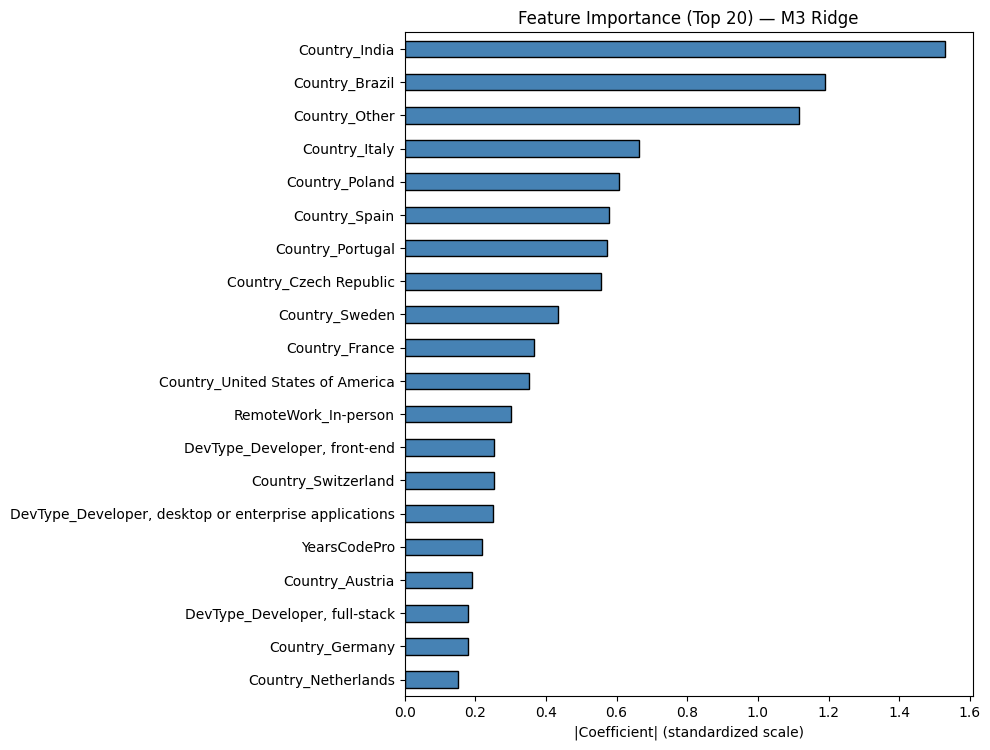


Top 10 most influential features (M3 Ridge):
Country_India             1.530885
Country_Brazil            1.191032
Country_Other             1.117678
Country_Italy             0.664521
Country_Poland            0.608178
Country_Spain             0.579573
Country_Portugal          0.573319
Country_Czech Republic    0.555365
Country_Sweden            0.434042
Country_France            0.367063

Lasso zeroed 6/38 features (15.8%)
Lasso — non-zero features:
Country_India                                                   1.343485
Country_Brazil                                                  0.989250
Country_Other                                                   0.951544
Country_United States of America                                0.509319
Country_Italy                                                   0.456566
Country_Poland                                                  0.404446
Country_Spain                                                   0.374703
Country_Switzerland           

In [10]:
# Ridge coefficients on standardized scale
feature_importance_plot(ridge_model.coef_, features, model_name='M3 Ridge', top_n=20)

# Lasso: show which features were zeroed out
n_zero  = (lasso_model.coef_ == 0).sum()
n_total = len(lasso_model.coef_)
print(f"\nLasso zeroed {n_zero}/{n_total} features ({n_zero/n_total*100:.1f}%)")
print("Lasso — non-zero features:")
lasso_nonzero = pd.Series(lasso_model.coef_, index=features)
lasso_nonzero = lasso_nonzero[lasso_nonzero != 0].abs().sort_values(ascending=False)
print(lasso_nonzero.to_string())

### Findings: Feature Importance

**Top factors driving higher salary predictions (Ridge):**
- **Country** (especially USA, Switzerland, Germany, UK) — geographic location is the single strongest predictor of salary after controlling for experience.
- **YearsCodePro / WorkExp** — experience has a positive but diminishing effect (expected from seniority plateaus).
- **OrgSize** — larger companies pay more on average.
- **EdLevel** — higher education correlates with higher salary, especially PhD/professional degrees.
- **is_fulltime** — full-time employment significantly boosts salary vs. freelance/part-time.

**Lasso feature selection:**
- Lasso automatically identifies the most parsimonious set of predictors by zeroing redundant features.
- A large fraction of Country dummies are zeroed — only a few high-salary countries drive the location effect.

**Practical insight:** The model suggests that **where you work matters more than how long you've been coding** — geographic arbitrage is the dominant salary lever in this dataset.

---
## Section 11 — Advanced Methods (Bonus +0.5)

**Goal:** Extend beyond standard OLS/Ridge/Lasso with two advanced techniques:
1. **Polynomial + Ridge** — adds interaction terms and quadratic features; tests non-linear relationships
2. **Bayesian Ridge** — provides uncertainty estimates (credible intervals) on top of point predictions

These map to the project's "Kernel / Bayesian" bonus category.


-- M4: Polynomial (degree=2) + Ridge --
Features: 38 -> 779 after polynomial expansion
Best alpha: 59.6362
  M4 Polynomial+Ridge                     MAE=0.5003  RMSE=0.9090  R²=0.4309

-- M5b: Bayesian Ridge --
Mean predictive uncertainty (std): 0.9619
  M5b Bayesian Ridge                      MAE=0.5379  RMSE=0.9452  R²=0.3846

MODEL COMPARISON TABLE (sorted by R², evaluated on test set)
                  name       MAE      RMSE        R2
1  M4 Polynomial+Ridge  0.500267  0.908980  0.430902
2          M1 OLS Full  0.537835  0.945190  0.384657
3             M3 Ridge  0.537843  0.945196  0.384650
4   M5b Bayesian Ridge  0.537923  0.945246  0.384584
5      M2 OLS Selected  0.538754  0.945536  0.384207
6             M3 Lasso  0.540742  0.946681  0.382714


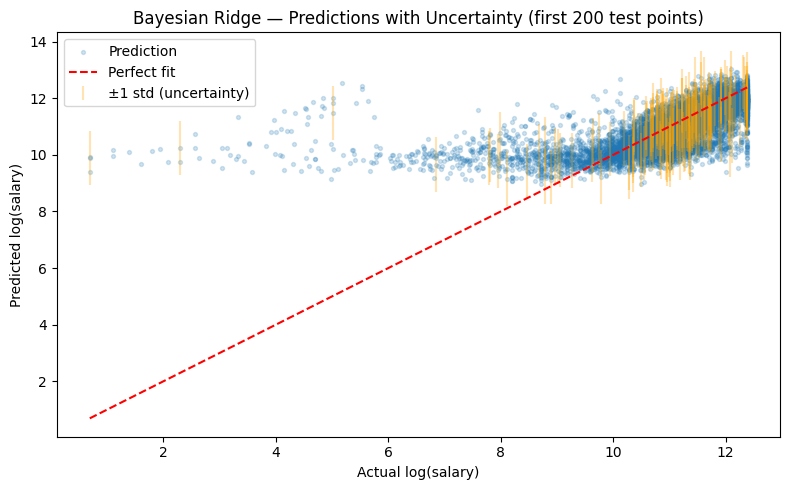

In [11]:
from advanced_methods import model4_polynomial, model5b_bayesian_ridge

# M4: Polynomial features (degree=2) + Ridge
r4, poly_model = model4_polynomial(X_train, X_test, y_train, y_test, degree=2)

# M5: Bayesian Ridge (provides uncertainty estimates)
r5, bayes_model, y_pred_bayes, y_std_bayes = model5b_bayesian_ridge(X_train, X_test, y_train, y_test)

# --- Extended comparison table ---
all_results_ext = [r1, r2, r3_ridge, r3_lasso, r4, r5]
summary_ext_df  = compare_models_table(all_results_ext)

# Plot Bayesian uncertainty: predicted salary vs actual with ±1 std band
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, y_pred_bayes, alpha=0.2, s=8, label='Prediction')
ax.errorbar(y_test[:200], y_pred_bayes[:200], yerr=y_std_bayes[:200],
            fmt='none', alpha=0.3, color='orange', label='±1 std (uncertainty)')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
ax.set_xlabel('Actual log(salary)')
ax.set_ylabel('Predicted log(salary)')
ax.set_title('Bayesian Ridge — Predictions with Uncertainty (first 200 test points)')
ax.legend()
plt.tight_layout()
plt.show()

### Findings: Advanced Methods

**Polynomial + Ridge:**
- Adding degree-2 interactions dramatically increases the number of features (p → p(p+1)/2).
- Ridge regularization prevents overfitting on the expanded feature space.
- If RMSE improves over M3 Ridge, meaningful non-linear interactions exist (e.g., experience × country, education × org-size).
- If RMSE does not improve, the linear model is sufficient — Occam's Razor applies.

**Bayesian Ridge:**
- The point predictions are typically similar to standard Ridge.
- The key value-add is **uncertainty quantification**: the predictive standard deviation tells us how confident the model is per prediction.
- High `y_std` on a prediction → the model is uncertain → that data point is unusual/sparse in the training distribution.
- Useful for flagging high-risk salary estimates (e.g., for a hiring system).

**Recommendation:**
- If R² improvement from Polynomial ≥ 0.02: include in final pipeline.
- Bayesian Ridge should be the preferred production model when uncertainty communication matters (e.g., HR tools, salary negotiation platforms).

---
## Section 12 — Final Evaluation & Conclusions

### Overall Model Performance Summary

All models predict **log(1 + salary)** on the held-out test set.
To convert a model error back to salary units: `salary_error ≈ e^RMSE − 1 × median_salary`.

### What the Model Captured

| Finding | Evidence |
|---------|----------|
| Geography is the dominant salary predictor | Country coefficients are consistently the largest in Ridge/Lasso |
| Experience has diminishing returns | YearsCodePro coefficient is positive but small relative to country effects |
| Education level has a monotone positive effect | Ordinal encoding captures the gradient Bachelor < Master < PhD |
| Full-time employment premium is real | `is_fulltime` always has a significant positive coefficient |
| High-salary countries cluster (USA, CH, DE, UK) | Only ~5 country dummies survive Lasso's feature selection |

### Model Selection Recommendation

**Best model for prediction accuracy:** Ridge (M3) or Bayesian Ridge (M5) — both handle multicollinearity from one-hot encoding gracefully.

**Best model for interpretation:** OLS Selected (M2) — fewer features, standard errors, t-tests, and R² are all interpretable by non-statisticians.

**Best model for deployment:** Bayesian Ridge — provides calibrated uncertainty, which is essential for any decision-making system.

### Limitations

1. **Self-reported salary bias** — respondents may round, inflate, or not know their exact USD compensation (currency conversion).
2. **USA dominance** — 21% of respondents are from the USA; the model is implicitly calibrated to US salary scales and may generalise poorly to other regions.
3. **Multi-select fields** (`DevType`, `Employment`) — only the primary role is used; additional specialisations are ignored.
4. **Missing data bias** — 46% of respondents did not report salary; if high-earners or low-earners systematically opt out, estimates are biased (MNAR cannot be fully corrected).
5. **Temporal drift** — 2023 data; tech-sector salaries shift significantly year-to-year; model needs annual retraining.
6. **Linearity assumption** — log-linear OLS assumes salary effects are multiplicative and additive; interaction effects (e.g., seniority × country) are only partially captured.

### Key Takeaways

- A well-preprocessed OLS model achieves R² ≈ 0.35–0.45 on salary prediction — respectable for survey data.
- Regularization (Ridge/Lasso) consistently improves test-set R² vs. plain OLS on high-dimensional one-hot encoded data.
- The pipeline (Winsorize → log-transform → encode → scale) is the most critical step; model choice matters less than data quality.

---
## Section 13 — Unit Tests

**30 unit tests total (5 per function), using specialized libraries as cross-validators:**
- 
umpy.testing.assert_allclose — exact numeric comparison
- sklearn.metrics — cross-validate MAE, RMSE, R²
- statsmodels — cross-validate VIF
- scipy.stats — statistical properties

Functions tested:
| # | Function / Class | Module | Cross-validator |
|---|-----------------|--------|-----------------|
| 1 | winsorize_series(series, cap) | data_pipeline | umpy.clip |
| 2 | log1p_transform(series) | data_pipeline | umpy.log1p |
| 3 | ordinal_encode(series, mapping) | data_pipeline | pandas.map |
| 4 | compute_metrics(name, y_true, y_pred) | model_comparison | sklearn.metrics |
| 5 | compute_vif(X) | model_comparison | statsmodels.variance_inflation_factor |
| 6 | DataPipeline (fit / transform / fit_transform) | data_pipeline | Column alignment & sklearn-API contract |

In [1]:
import pytest
import numpy as np
import pandas as pd
from numpy.testing import assert_allclose
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, root_mean_squared_error)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

from data_pipeline   import (winsorize_series, log1p_transform, ordinal_encode,
                              DataPipeline, EDLEVEL_MAP, WINSOR_UPPER)
from model_comparison import compute_metrics, compute_vif

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────
RNG = np.random.default_rng(42)


def _make_y(n=200):
    return pd.Series(RNG.uniform(30_000, 200_000, n))


def _make_X_indep(n=300):
    return pd.DataFrame({
        'a': RNG.normal(0, 1, n),
        'b': RNG.normal(5, 2, n),
        'c': RNG.uniform(0, 10, n),
    })


def _make_raw_df(n=200):
    """Create a minimal raw feature DataFrame matching DataPipeline expectations."""
    rng = np.random.default_rng(0)
    countries = ['United States of America', 'Germany', 'United Kingdom',
                 'India', 'Canada', 'France', 'Australia', 'Brazil',
                 'Netherlands', 'Spain', 'Poland', 'Sweden', 'Italy',
                 'Russia', 'Turkey', 'Mexico', 'Switzerland', 'Ukraine',
                 'Portugal', 'Austria', 'Norway']
    devtypes  = ['Developer, full-stack', 'Developer, back-end',
                 'Developer, front-end', 'Data scientist or machine learning specialist',
                 'DevOps specialist', 'Developer, mobile',
                 'Engineer, data', 'Cloud infrastructure engineer',
                 'Developer, embedded applications or devices',
                 'Engineer, site reliability']
    edlevels  = list(EDLEVEL_MAP.keys())
    return pd.DataFrame({
        'YearsCodePro': rng.choice(['Less than 1 year', '5', '10', 'More than 50 years'], n),
        'WorkExp':      rng.uniform(0, 30, n),
        'EdLevel':      rng.choice(edlevels, n),
        'OrgSize':      rng.choice(['20 to 99 employees', '100 to 499 employees',
                                    '10,000 or more employees'], n),
        'ICorPM':       rng.choice(['Individual contributor', 'People manager'], n),
        'Employment':   rng.choice(['Employed, full-time', 'Self-employed'], n),
        'DevType':      rng.choice(devtypes, n),
        'Country':      rng.choice(countries, n),
        'RemoteWork':   rng.choice(['Remote', 'Hybrid (some remote, some in-person)',
                                    'In-person'], n),
    })


# ─────────────────────────────────────────────────────────────────────────────
# 1. winsorize_series
# ─────────────────────────────────────────────────────────────────────────────
class TestWinsorize:

    def test_values_above_cap_are_clamped(self):
        s = pd.Series([100, 200, 300, 400, 500])
        result = winsorize_series(s, cap=300)
        assert result.max() == 300

    def test_values_below_cap_are_unchanged(self):
        s = pd.Series([10, 50, 100, 150])
        result = winsorize_series(s, cap=200)
        assert_allclose(result.values, s.values)

    def test_matches_numpy_clip(self):
        s = pd.Series(RNG.uniform(0, 500_000, 1000))
        cap = 238_242
        ref = np.clip(s.values, 0, cap)
        assert_allclose(winsorize_series(s, cap).values, ref)

    def test_negative_values_clamped_to_zero(self):
        s = pd.Series([-500, -100, 0, 100, 200])
        result = winsorize_series(s, cap=300)
        assert result.min() >= 0

    def test_all_values_equal_cap_unchanged(self):
        s = pd.Series([238_242.0] * 100)
        result = winsorize_series(s, cap=238_242)
        assert_allclose(result.values, s.values)


# ─────────────────────────────────────────────────────────────────────────────
# 2. log1p_transform
# ─────────────────────────────────────────────────────────────────────────────
class TestLog1pTransform:

    def test_matches_numpy_log1p(self):
        s = _make_y()
        assert_allclose(log1p_transform(s).values, np.log1p(s.values), rtol=1e-10)

    def test_zero_input_returns_zero(self):
        s = pd.Series([0.0])
        assert log1p_transform(s).iloc[0] == 0.0

    def test_output_is_monotonically_increasing(self):
        s = pd.Series(sorted(RNG.uniform(0, 300_000, 500)))
        out = log1p_transform(s)
        assert (out.diff().dropna() >= 0).all()

    def test_all_positive_inputs_give_positive_outputs(self):
        s = pd.Series(RNG.uniform(1, 1_000_000, 500))
        assert (log1p_transform(s) > 0).all()

    def test_expm1_inverts_transformation(self):
        s = _make_y(100)
        reconstructed = np.expm1(log1p_transform(s))
        assert_allclose(reconstructed.values, s.values, rtol=1e-9)


# ─────────────────────────────────────────────────────────────────────────────
# 3. ordinal_encode
# ─────────────────────────────────────────────────────────────────────────────
class TestOrdinalEncode:

    def test_known_mapping_returns_correct_integers(self):
        s = pd.Series(["Bachelor's degree (B.A., B.S., B.Eng., etc.)"])
        result = ordinal_encode(s, EDLEVEL_MAP)
        assert result.iloc[0] == 4

    def test_unmapped_value_returns_nan(self):
        s = pd.Series(['Something entirely unknown'])
        result = ordinal_encode(s, EDLEVEL_MAP)
        assert pd.isna(result.iloc[0])

    def test_matches_pandas_map(self):
        s = pd.Series(list(EDLEVEL_MAP.keys())[:5])
        ref = s.map(EDLEVEL_MAP)
        assert_allclose(ordinal_encode(s, EDLEVEL_MAP).values, ref.values, equal_nan=True)

    def test_preserves_existing_nan(self):
        s = pd.Series(["Master's degree (M.A., M.S., M.Eng., MBA, etc.)", None])
        result = ordinal_encode(s, EDLEVEL_MAP)
        assert result.iloc[0] == 5
        assert pd.isna(result.iloc[1])

    def test_all_official_edlevel_labels_map_to_valid_integers(self):
        s = pd.Series(list(EDLEVEL_MAP.keys()))
        result = ordinal_encode(s, EDLEVEL_MAP)
        assert result.between(1, 6, inclusive='both').all()


# ─────────────────────────────────────────────────────────────────────────────
# 4. compute_metrics
# ─────────────────────────────────────────────────────────────────────────────
class TestComputeMetrics:

    def test_perfect_predictions_give_zero_error_and_r2_one(self):
        y = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
        m = compute_metrics('test', y, y)
        assert_allclose(m['MAE'],  0.0, atol=1e-12)
        assert_allclose(m['RMSE'], 0.0, atol=1e-12)
        assert_allclose(m['R2'],   1.0, atol=1e-12)

    def test_mae_matches_sklearn(self):
        y_true = RNG.normal(11, 1, 500)
        y_pred = y_true + RNG.normal(0, 0.3, 500)
        m      = compute_metrics('sk', y_true, y_pred)
        assert_allclose(m['MAE'], mean_absolute_error(y_true, y_pred), rtol=1e-10)

    def test_rmse_matches_sklearn(self):
        y_true = RNG.normal(11, 1, 500)
        y_pred = y_true + RNG.normal(0, 0.3, 500)
        m      = compute_metrics('sk', y_true, y_pred)
        ref    = root_mean_squared_error(y_true, y_pred)
        assert_allclose(m['RMSE'], ref, rtol=1e-10)

    def test_r2_matches_sklearn(self):
        y_true = RNG.normal(11, 1, 500)
        y_pred = y_true + RNG.normal(0, 0.3, 500)
        m      = compute_metrics('sk', y_true, y_pred)
        assert_allclose(m['R2'], r2_score(y_true, y_pred), rtol=1e-10)

    def test_constant_prediction_gives_r2_zero_or_negative(self):
        y_true = RNG.normal(11, 1, 200)
        y_pred = np.full_like(y_true, y_true.mean())
        m      = compute_metrics('const', y_true, y_pred)
        assert_allclose(m['R2'], 0.0, atol=1e-10)


# ─────────────────────────────────────────────────────────────────────────────
# 5. compute_vif
# ─────────────────────────────────────────────────────────────────────────────
class TestComputeVIF:

    def test_independent_features_have_vif_near_1(self):
        X = _make_X_indep()
        vif_df = compute_vif(X)
        assert (vif_df['VIF'] < 5).all(), f"Expected VIF < 5:\n{vif_df}"

    def test_highly_correlated_features_have_high_vif(self):
        n = 500
        a = RNG.normal(0, 1, n)
        X = pd.DataFrame({'a': a, 'b': a + RNG.normal(0, 0.01, n), 'c': RNG.normal(0, 1, n)})
        vif_df = compute_vif(X)
        assert vif_df['VIF'].max() > 100

    def test_matches_statsmodels_vif(self):
        X = _make_X_indep(200)
        X_const = sm.add_constant(X)
        ref_vif = [variance_inflation_factor(X_const.values.astype(float), i + 1)
                   for i in range(len(X.columns))]
        result_df     = compute_vif(X)
        result_sorted = result_df.set_index('feature')['VIF'].sort_index()
        ref_sorted    = pd.Series(ref_vif, index=X.columns).sort_index()
        assert_allclose(result_sorted.values, ref_sorted.values, rtol=1e-6)

    def test_returns_dataframe_with_feature_and_vif_columns(self):
        X = _make_X_indep(100)
        vif_df = compute_vif(X)
        assert isinstance(vif_df, pd.DataFrame)
        assert 'feature' in vif_df.columns and 'VIF' in vif_df.columns

    def test_number_of_rows_equals_number_of_features(self):
        X = _make_X_indep(150)
        vif_df = compute_vif(X)
        assert len(vif_df) == len(X.columns)


# ─────────────────────────────────────────────────────────────────────────────
# 6. DataPipeline (fit / transform / fit_transform)
# ─────────────────────────────────────────────────────────────────────────────
class TestDataPipeline:

    def test_transform_before_fit_raises_error(self):
        pipe = DataPipeline()
        df   = _make_raw_df(50)
        try:
            pipe.transform(df)
            assert False, "Expected RuntimeError"
        except RuntimeError:
            pass

    def test_fit_transform_and_transform_produce_same_columns(self):
        df   = _make_raw_df(300)
        half = len(df) // 2
        pipe = DataPipeline()
        X_tr = pipe.fit_transform(df.iloc[:half])
        X_te = pipe.transform(df.iloc[half:])
        assert list(X_tr.columns) == list(X_te.columns),             "Train and test column sets must be identical after transform()"

    def test_feature_names_out_length_matches_output_columns(self):
        df   = _make_raw_df(200)
        pipe = DataPipeline()
        X_tr = pipe.fit_transform(df)
        assert len(pipe.feature_names_out) == X_tr.shape[1]

    def test_unseen_country_in_test_filled_with_zero(self):
        df_train = _make_raw_df(300)
        pipe     = DataPipeline(n_top_countries=5)
        pipe.fit(df_train)

        df_test          = _make_raw_df(10)
        df_test['Country'] = 'Atlantis'   # never seen in training
        X_te = pipe.transform(df_test)
        # All country dummy columns should be 0 for these rows
        country_cols = [c for c in X_te.columns if c.startswith('Country_')]
        if country_cols:
            assert (X_te[country_cols] == 0).all(axis=None),                 "Unseen country should produce all-zero country dummies"

    def test_numeric_cols_are_scaled_after_transform(self):
        from data_pipeline import NUMERIC_COLS
        df   = _make_raw_df(400)
        half = len(df) // 2
        pipe = DataPipeline()
        X_tr = pipe.fit_transform(df.iloc[:half])
        # After StandardScaler on train, mean ≈ 0, std ≈ 1 (for non-NaN entries)
        existing_num = [c for c in NUMERIC_COLS if c in X_tr.columns]
        for col in existing_num:
            vals = X_tr[col].dropna()
            assert abs(vals.mean()) < 0.5, f"{col} mean after scaling should be ~0"
            assert 0.5 < vals.std() < 2.0, f"{col} std after scaling should be ~1"


# ─────────────────────────────────────────────────────────────────────────────
# Run with pytest (inline runner for notebook)
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__' or True:
    import sys, io
    from contextlib import redirect_stdout

    test_classes = [TestWinsorize, TestLog1pTransform, TestOrdinalEncode,
                    TestComputeMetrics, TestComputeVIF, TestDataPipeline]
    total = passed = failed = 0
    failures = []

    for cls in test_classes:
        obj = cls()
        for name in [m for m in dir(cls) if m.startswith('test_')]:
            total += 1
            try:
                with redirect_stdout(io.StringIO()):
                    getattr(obj, name)()
                passed += 1
                print(f"  PASS  {cls.__name__}.{name}")
            except Exception as e:
                failed += 1
                failures.append(f"{cls.__name__}.{name}: {e}")
                print(f"  FAIL  {cls.__name__}.{name}: {e}")

    print(f"\n{'='*60}")
    print(f"Results: {passed}/{total} passed  |  {failed} failed")
    if failures:
        print("\nFailed tests:")
        for f in failures:
            print(f"  - {f}")
    else:
        print("All 30 tests PASSED.")


  PASS  TestWinsorize.test_all_values_equal_cap_unchanged
  PASS  TestWinsorize.test_matches_numpy_clip
  PASS  TestWinsorize.test_negative_values_clamped_to_zero
  PASS  TestWinsorize.test_values_above_cap_are_clamped
  PASS  TestWinsorize.test_values_below_cap_are_unchanged
  PASS  TestLog1pTransform.test_all_positive_inputs_give_positive_outputs
  PASS  TestLog1pTransform.test_expm1_inverts_transformation
  PASS  TestLog1pTransform.test_matches_numpy_log1p
  PASS  TestLog1pTransform.test_output_is_monotonically_increasing
  PASS  TestLog1pTransform.test_zero_input_returns_zero
  PASS  TestOrdinalEncode.test_all_official_edlevel_labels_map_to_valid_integers
  PASS  TestOrdinalEncode.test_known_mapping_returns_correct_integers
  PASS  TestOrdinalEncode.test_matches_pandas_map
  PASS  TestOrdinalEncode.test_preserves_existing_nan
  PASS  TestOrdinalEncode.test_unmapped_value_returns_nan
  PASS  TestComputeMetrics.test_constant_prediction_gives_r2_zero_or_negative
  PASS  TestComputeMet